/tmp/ipykernel_13569/2866879411.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


✓ Saved: network_200.png


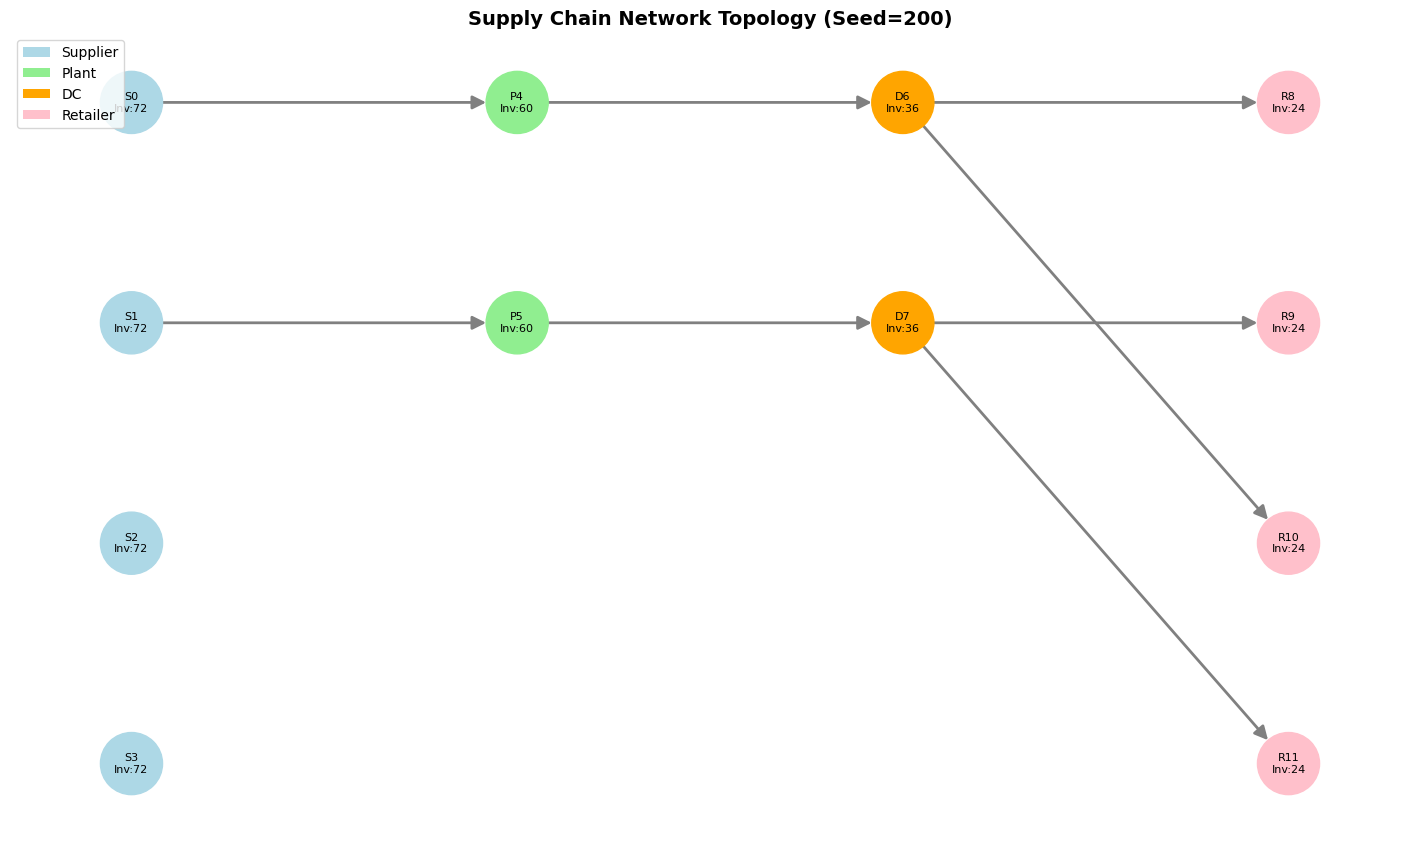

In [3]:
from model import MultiTierModel
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

SEED = 200  # Đổi seed muốn xem

assumptions = {
    "n_suppliers": 4,
    "n_plants": 2,
    "n_dcs": 2,
    "n_retailers": 4,
    "base_stock": {"supplier": 60, "plant": 50, "dc": 30, "retailer": 20},
    "capacity": {"supplier": 50, "plant": 60, "dc": 0, "retailer": 0},
    "lead_time": {"supplier": 3, "plant": 2, "dc": 2, "retailer": 1},
}

# Tạo model
model = MultiTierModel(
    assumptions=assumptions,
    seed=SEED,
    strategies={"dual_sourcing": False},
    disruption_at_step=10,
    scenario="capacity_loss",
    n_steps=120
)

G = model.G

# Positions theo tier
pos = {}
tier_x = {"supplier": 0, "plant": 1, "dc": 2, "retailer": 3}
tier_counts = {"supplier": 0, "plant": 0, "dc": 0, "retailer": 0}

for agent in model.all_agents:
    x = tier_x[agent.tier]
    y = tier_counts[agent.tier]
    pos[agent.unique_id] = (x, -y)
    tier_counts[agent.tier] += 1

# Màu theo tier
color_map = {"supplier": "lightblue", "plant": "lightgreen", "dc": "orange", "retailer": "pink"}
colors = [color_map[a.tier] for a in model.all_agents]

# Labels với thông tin
labels = {}
for a in model.all_agents:
    labels[a.unique_id] = f"{a.tier[0].upper()}{a.unique_id}\nInv:{a.base_stock}"

# Vẽ
plt.figure(figsize=(14, 8))
nx.draw(G, pos,
        node_color=colors,
        node_size=2000,
        labels=labels,
        font_size=8,
        arrows=True,
        arrowsize=20,
        edge_color="gray",
        width=2)

# Legend
legend_elements = [
    Patch(facecolor='lightblue', label='Supplier'),
    Patch(facecolor='lightgreen', label='Plant'),
    Patch(facecolor='orange', label='DC'),
    Patch(facecolor='pink', label='Retailer'),
]
plt.legend(handles=legend_elements, loc='upper left', fontsize=10)

plt.title(f"Supply Chain Network Topology (Seed={SEED})", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"network_{SEED}.png", dpi=300, bbox_inches='tight')
print(f"✓ Saved: network_{SEED}.png")
plt.show()